# Primary Space Usage EDA

Primary-space-usage profiling of electricity consumption, data quality, temporal patterns, and site interactions.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../../data/building-data-genome-project-2/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'
from collections import defaultdict
from matplotlib.patches import Patch


In [ ]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']
elec_idx = elec.set_index('timestamp')

meta = pd.read_csv(META_PATH)
elec_bld_set = set(building_cols)
meta_bld_set = set(meta['building_id'].dropna())
matched = elec_bld_set & meta_bld_set

print(f'Electricity shape       : {elec.shape}')
print(f'Building columns        : {len(building_cols):,}')
print(f'Metadata shape          : {meta.shape}')
print(f'Matched buildings       : {len(matched):,}')


## 1. Map Buildings to Usage Types

In [31]:
# Build usage -> building list mapping (only buildings with electricity data)
meta_elec_usage = meta[meta['building_id'].isin(building_cols)][
    ['building_id', 'primaryspaceusage']
].copy()

bld_to_usage = meta_elec_usage.set_index('building_id')['primaryspaceusage'].to_dict()

usage_to_blds = defaultdict(list)
for bld, usage in bld_to_usage.items():
    if pd.notna(usage):
        usage_to_blds[usage].append(bld)
usage_to_blds = dict(usage_to_blds)

usages = sorted(usage_to_blds.keys())
usage_counts_series = pd.Series({u: len(usage_to_blds[u]) for u in usages}).sort_values(ascending=False)

print(f'Distinct primary usage types : {len(usages)}')
print()
print(usage_counts_series.rename('building_count').to_frame().to_string())

Distinct primary usage types : 16

                               building_count
Education                                 604
Office                                    296
Entertainment/public assembly             203
Public services                           166
Lodging/residential                       149
Healthcare                                 27
Other                                      26
Parking                                    23
Warehouse/storage                          14
Manufacturing/industrial                   11
Retail                                     11
Services                                    9
Technology/science                          7
Food sales and service                      6
Utility                                     4
Religious worship                           3


## 2. Consumption Statistics by Usage Type

,usage,n_buildings,total_kwh,mean_kwh,median_kwh,std_kwh,p95_kwh,p99_kwh,max_kwh
0,Education,604,"1,866,063,421.06",191.79,87.20,331.81,730.16,"1,445.40","221,228.00"
1,Office,296,"710,857,281.54",148.89,61.10,277.85,580.93,"1,424.72","44,336.46"
2,Entertainment/public assembly,203,"331,642,283.54",104.98,29.17,196.64,452.77,956.00,"11,624.00"
3,Public services,166,"255,599,848.46",94.14,35.61,176.88,369.67,"1,061.64","3,895.00"
4,Lodging/residential,149,"216,483,310.37",89.57,57.61,108.89,285.52,459.00,"12,576.00"
5,Healthcare,27,"133,742,721.12",308.16,188.92,372.97,"1,184.88","1,722.24","2,225.28"
6,Other,26,"19,407,747.01",46.80,12.65,99.07,356.37,414.64,"1,564.17"
7,Parking,23,"16,312,426.85",46.37,36.01,36.06,120.73,166.52,381.77
8,Manufacturing/industrial,11,"14,570,575.16",77.13,38.74,89.79,270.45,333.48,386.30
9,Services,9,"14,237,160.05",91.28,73.62,76.06,233.21,344.79,716.66


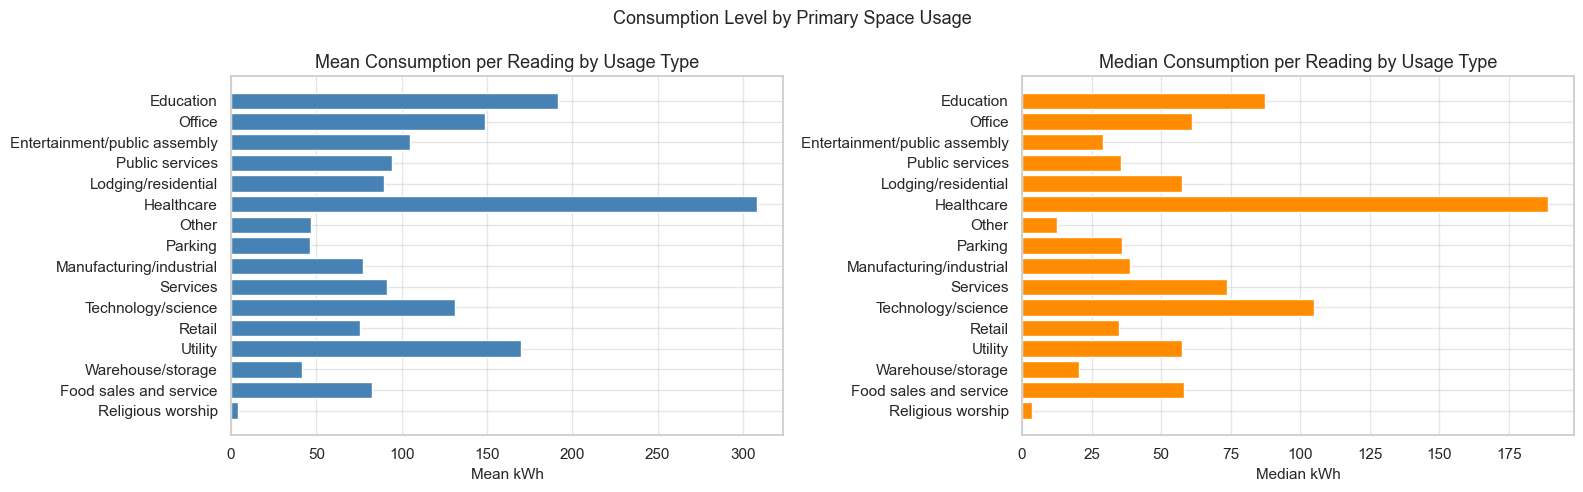

In [32]:
def usage_consumption_stats(usage):
    cols = usage_to_blds[usage]
    vals = elec[cols].values.ravel()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return {}
    return {
        'usage'         : usage,
        'n_buildings'   : len(cols),
        'total_kwh'     : vals.sum(),
        'mean_kwh'      : vals.mean(),
        'median_kwh'    : np.median(vals),
        'std_kwh'       : vals.std(),
        'p95_kwh'       : np.percentile(vals, 95),
        'p99_kwh'       : np.percentile(vals, 99),
        'max_kwh'       : vals.max(),
    }

usage_cons_df = pd.DataFrame([usage_consumption_stats(u) for u in usages])
usage_cons_df.sort_values('total_kwh', ascending=False, inplace=True)
usage_cons_df.reset_index(drop=True, inplace=True)

fmt = {c: '{:,.2f}' for c in usage_cons_df.columns if c not in ('usage', 'n_buildings')}
fmt['n_buildings'] = '{:,}'
display(usage_cons_df.style.format(fmt))

# Bar chart: mean and median consumption per usage type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = usage_cons_df['usage'].tolist()
x = range(len(order))

axes[0].barh(order, usage_cons_df['mean_kwh'], color='steelblue', edgecolor='white')
axes[0].set_title('Mean Consumption per Reading by Usage Type')
axes[0].set_xlabel('Mean kWh')
axes[0].invert_yaxis()

axes[1].barh(order, usage_cons_df['median_kwh'], color='darkorange', edgecolor='white')
axes[1].set_title('Median Consumption per Reading by Usage Type')
axes[1].set_xlabel('Median kWh')
axes[1].invert_yaxis()

plt.suptitle('Consumption Level by Primary Space Usage', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Data Quality by Usage Type

,usage,n_buildings,total_readings,missing,missing_rate,zeros,zero_rate,negatives,negative_rate
0,Technology/science,7,"122,808","23,131",18.84%,0,0.00%,0,0.00%
1,Parking,23,"403,512","51,759",12.83%,0,0.00%,0,0.00%
2,Entertainment/public assembly,203,"3,561,432","402,263",11.29%,0,0.00%,0,0.00%
3,Retail,11,"192,984","20,365",10.55%,0,0.00%,0,0.00%
4,Warehouse/storage,14,"245,616","22,332",9.09%,0,0.00%,0,0.00%
5,Other,26,"456,144","41,410",9.08%,0,0.00%,0,0.00%
6,Healthcare,27,"473,688","39,688",8.38%,0,0.00%,0,0.00%
7,Education,604,"10,596,576","866,664",8.18%,0,0.00%,0,0.00%
8,Office,296,"5,193,024","418,805",8.06%,0,0.00%,0,0.00%
9,Lodging/residential,149,"2,614,056","197,123",7.54%,0,0.00%,0,0.00%


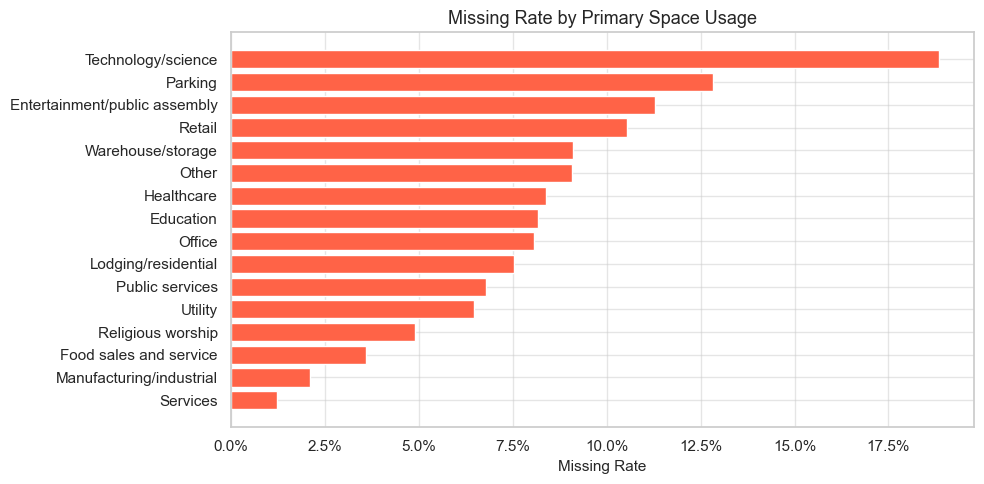

In [33]:
def usage_quality_stats(usage):
    cols = usage_to_blds[usage]
    sub  = elec[cols]
    total    = sub.size
    missing  = sub.isna().sum().sum()
    valid    = total - missing
    zero     = (sub == 0).sum().sum()
    negative = (sub < 0).sum().sum()
    return {
        'usage'         : usage,
        'n_buildings'   : len(cols),
        'total_readings': total,
        'missing'       : missing,
        'missing_rate'  : missing / total if total else np.nan,
        'zeros'         : zero,
        'zero_rate'     : zero / valid if valid else np.nan,
        'negatives'     : negative,
        'negative_rate' : negative / valid if valid else np.nan,
    }

usage_qual_df = pd.DataFrame([usage_quality_stats(u) for u in usages])
usage_qual_df.sort_values('missing_rate', ascending=False, inplace=True)
usage_qual_df.reset_index(drop=True, inplace=True)

fmt = {c: '{:.2%}' for c in ['missing_rate', 'zero_rate', 'negative_rate']}
fmt.update({c: '{:,}' for c in ['total_readings', 'missing', 'zeros', 'negatives', 'n_buildings']})
display(usage_qual_df.style.format(fmt))

# Missing rate bar
fig, ax = plt.subplots(figsize=(10, 5))
order_q = usage_qual_df['usage'].tolist()
ax.barh(order_q, usage_qual_df['missing_rate'], color='tomato', edgecolor='white')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Missing Rate by Primary Space Usage')
ax.set_xlabel('Missing Rate')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Temporal Profiles by Usage Type

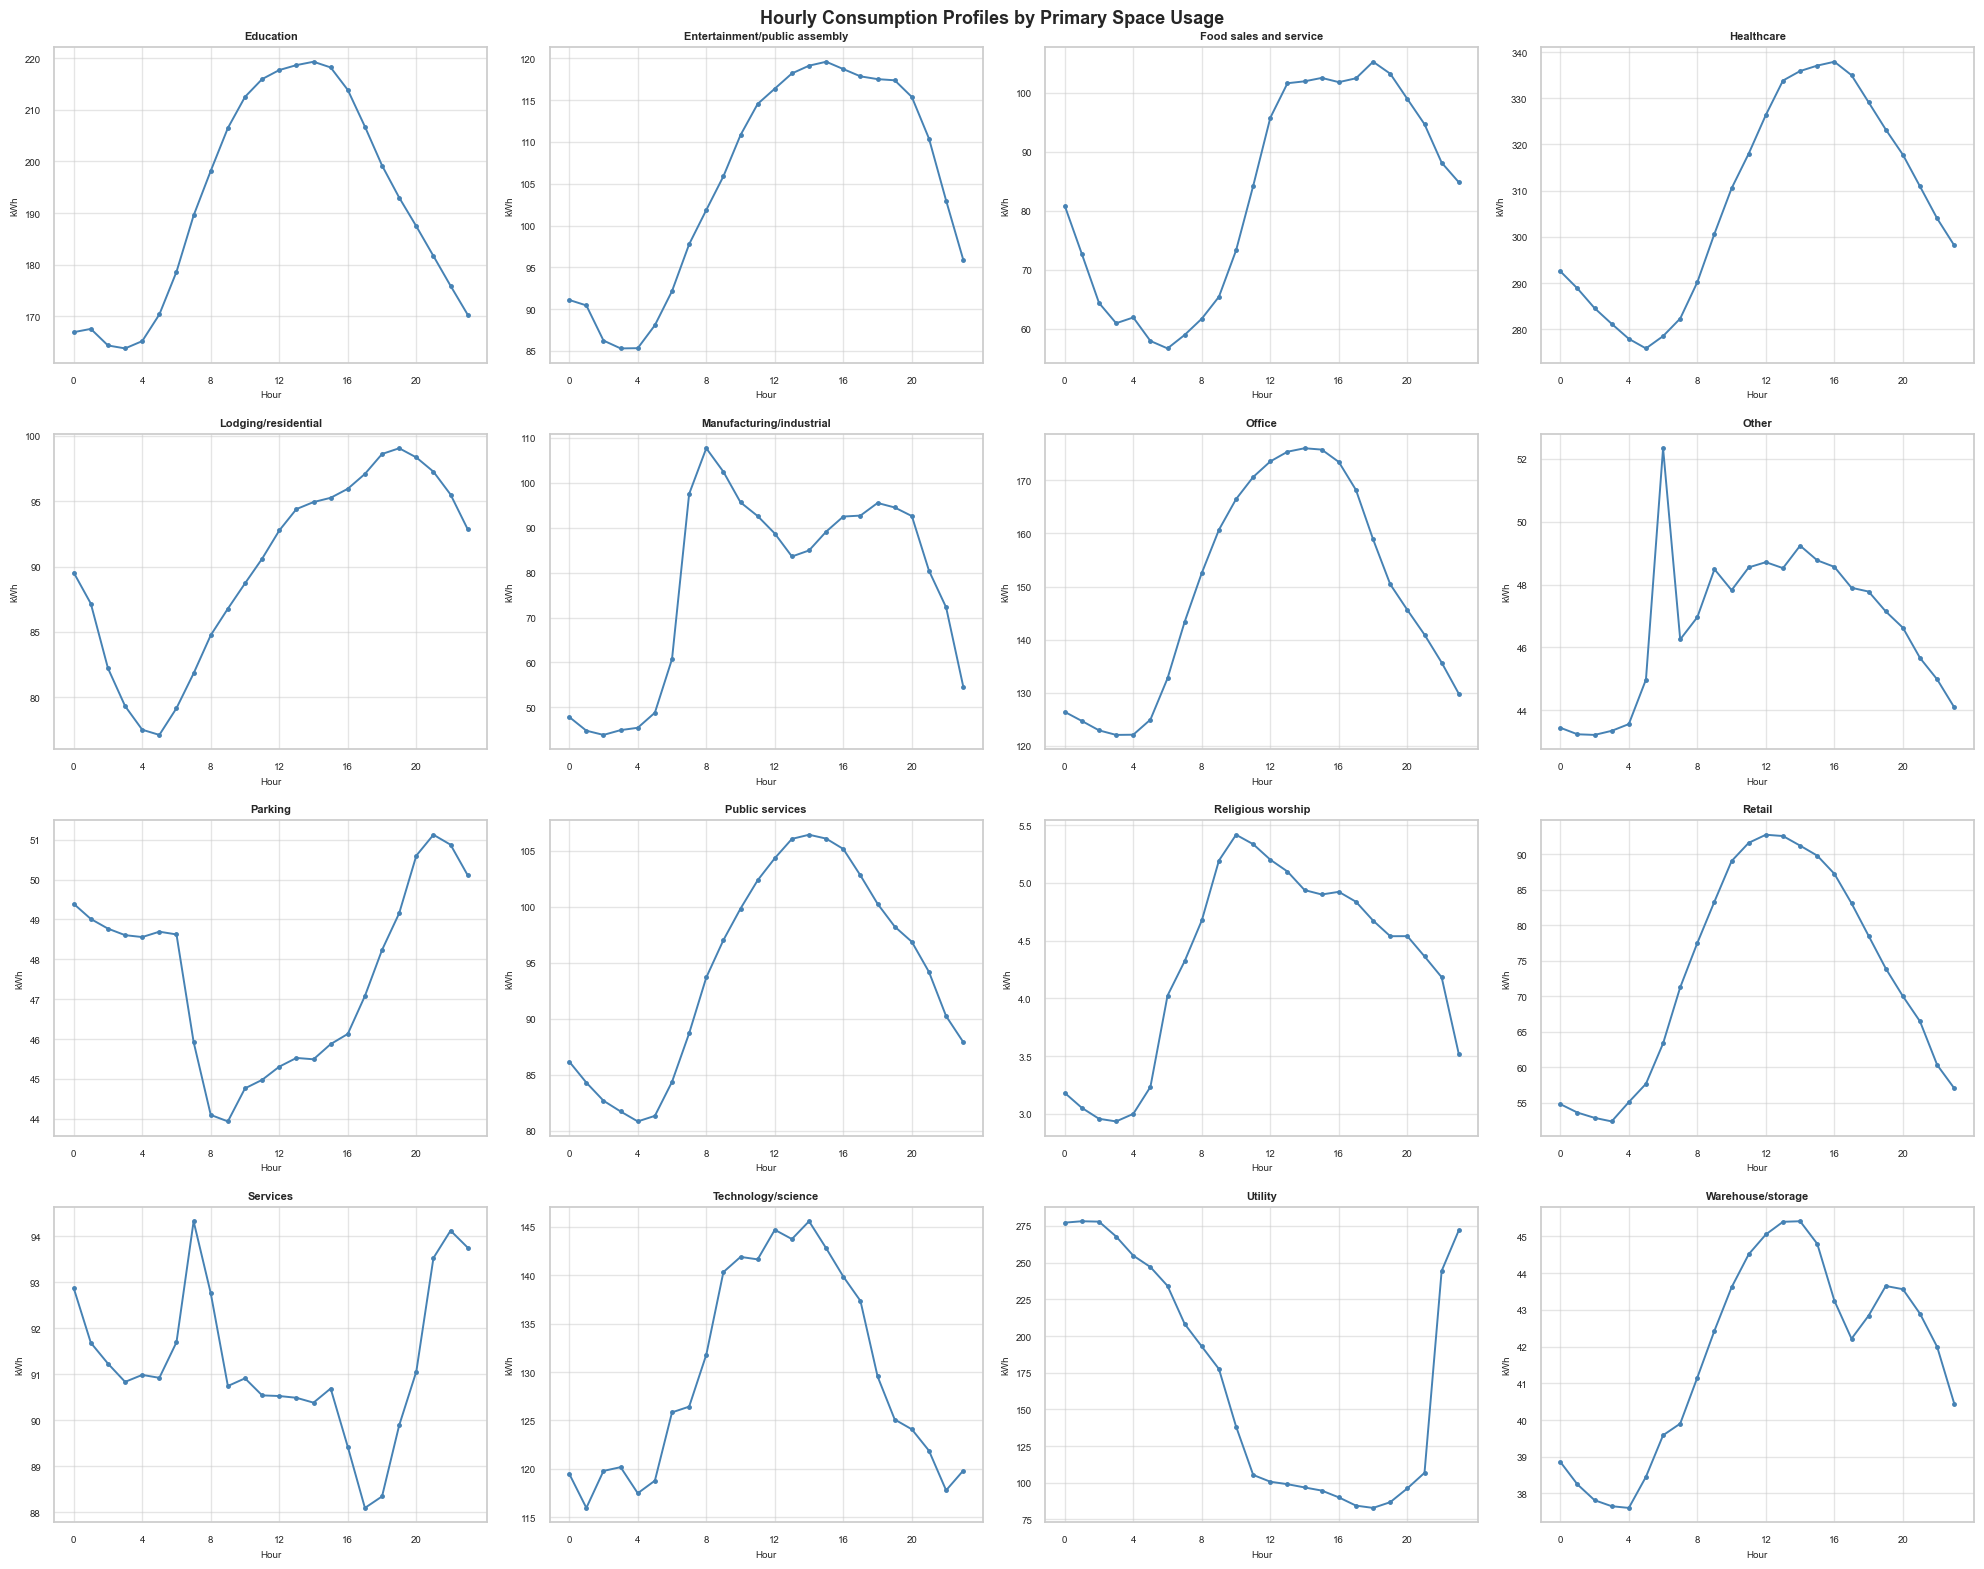

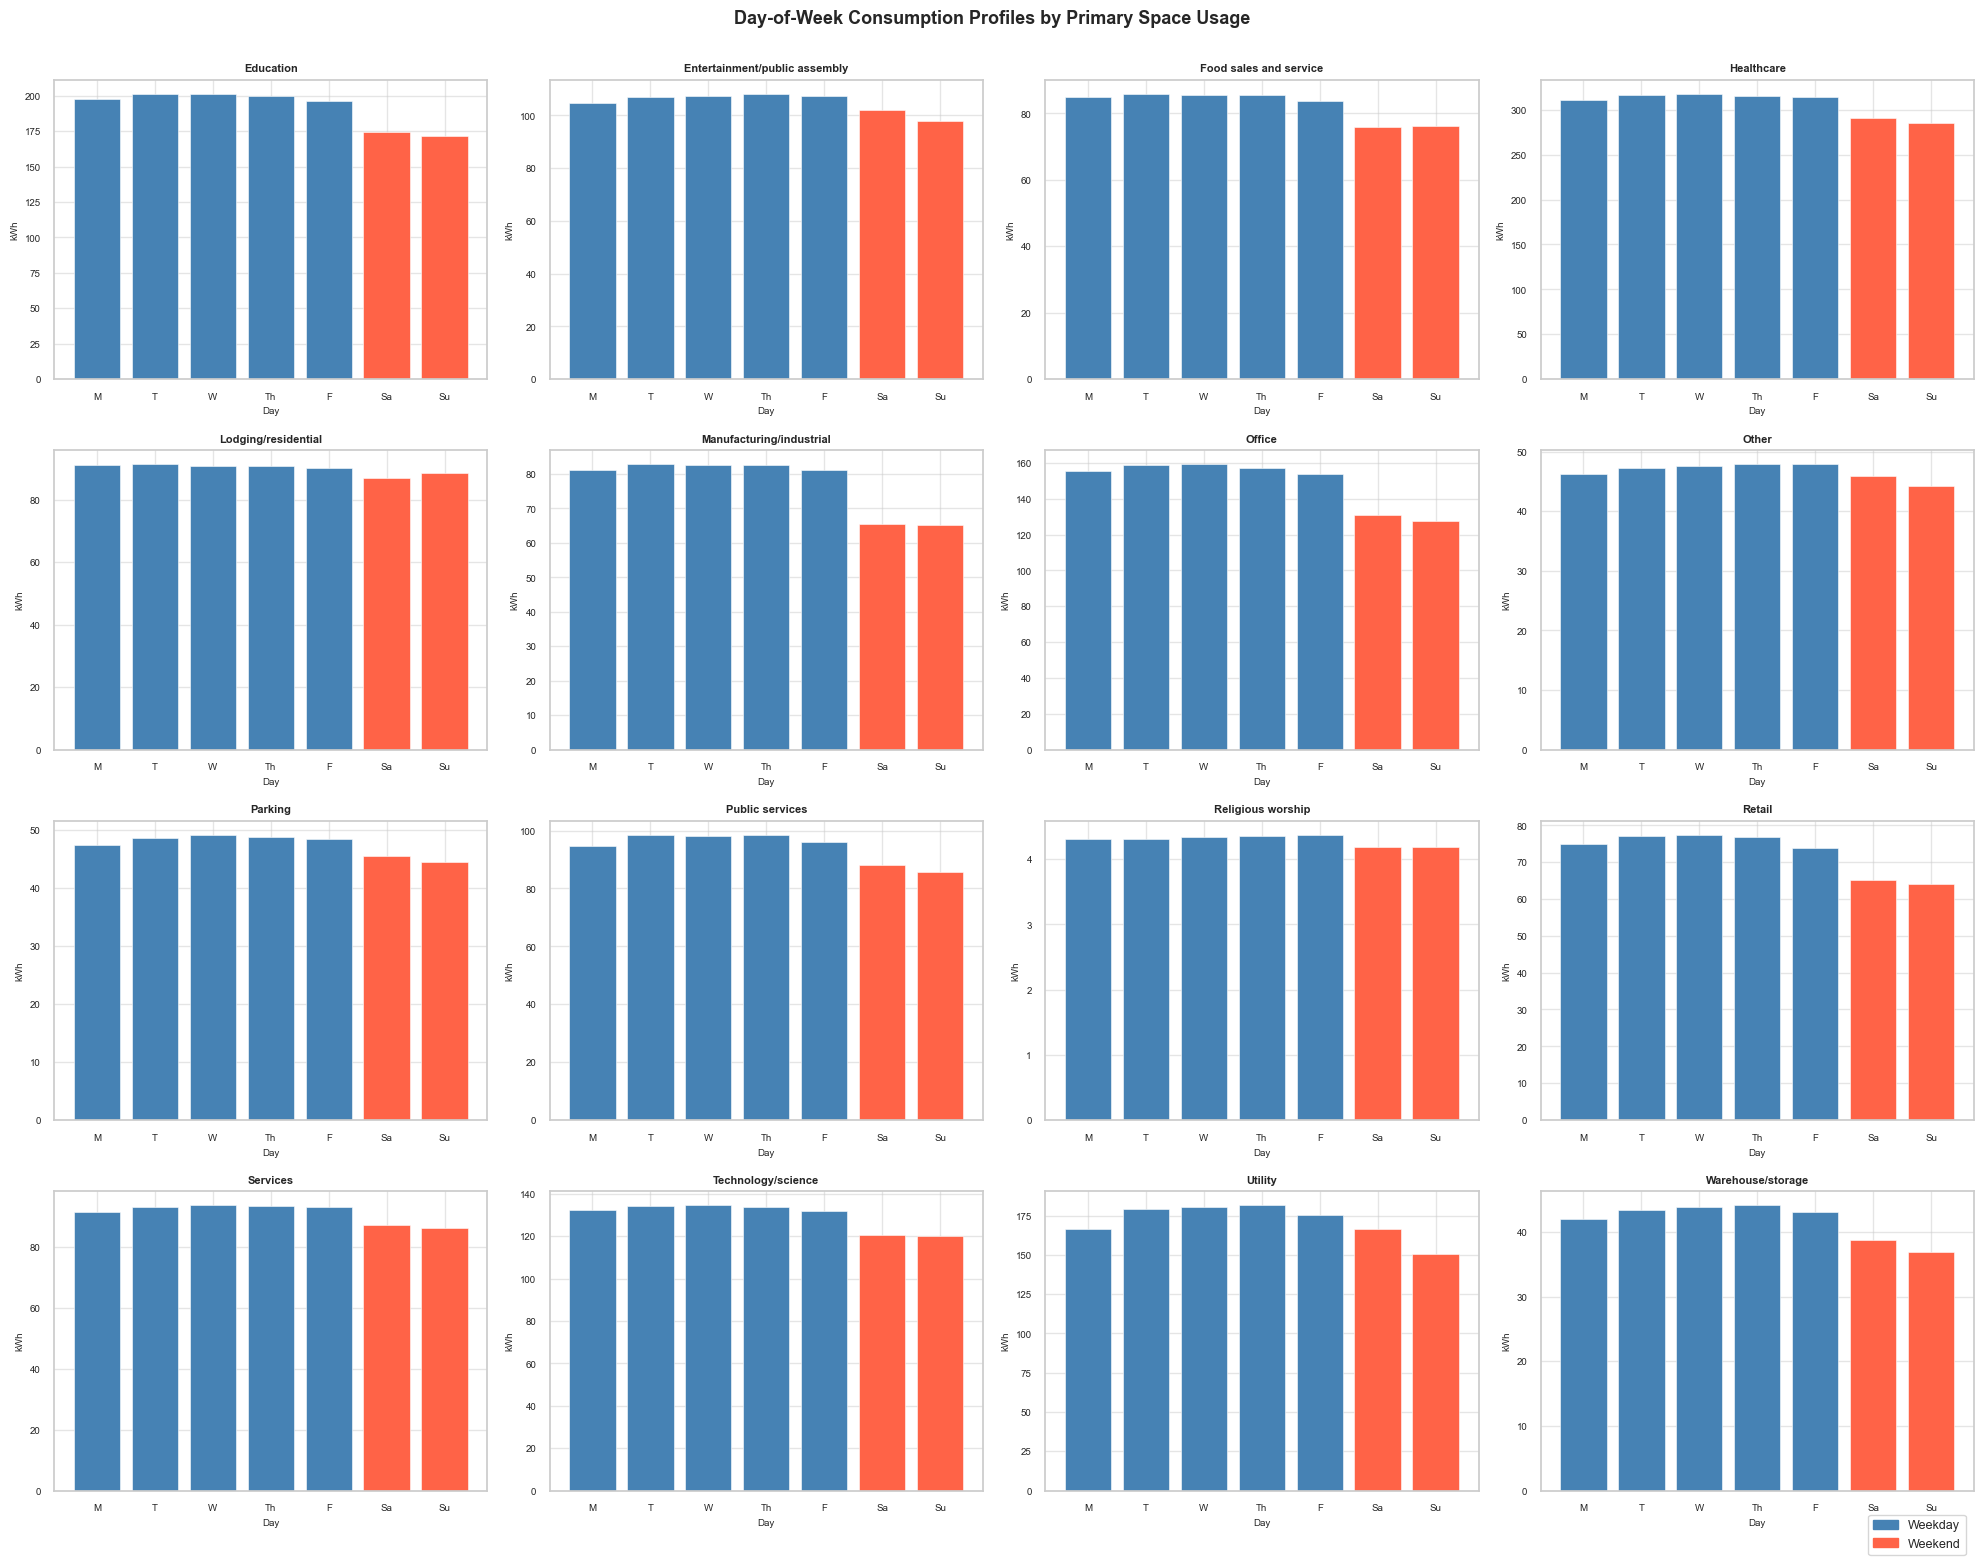

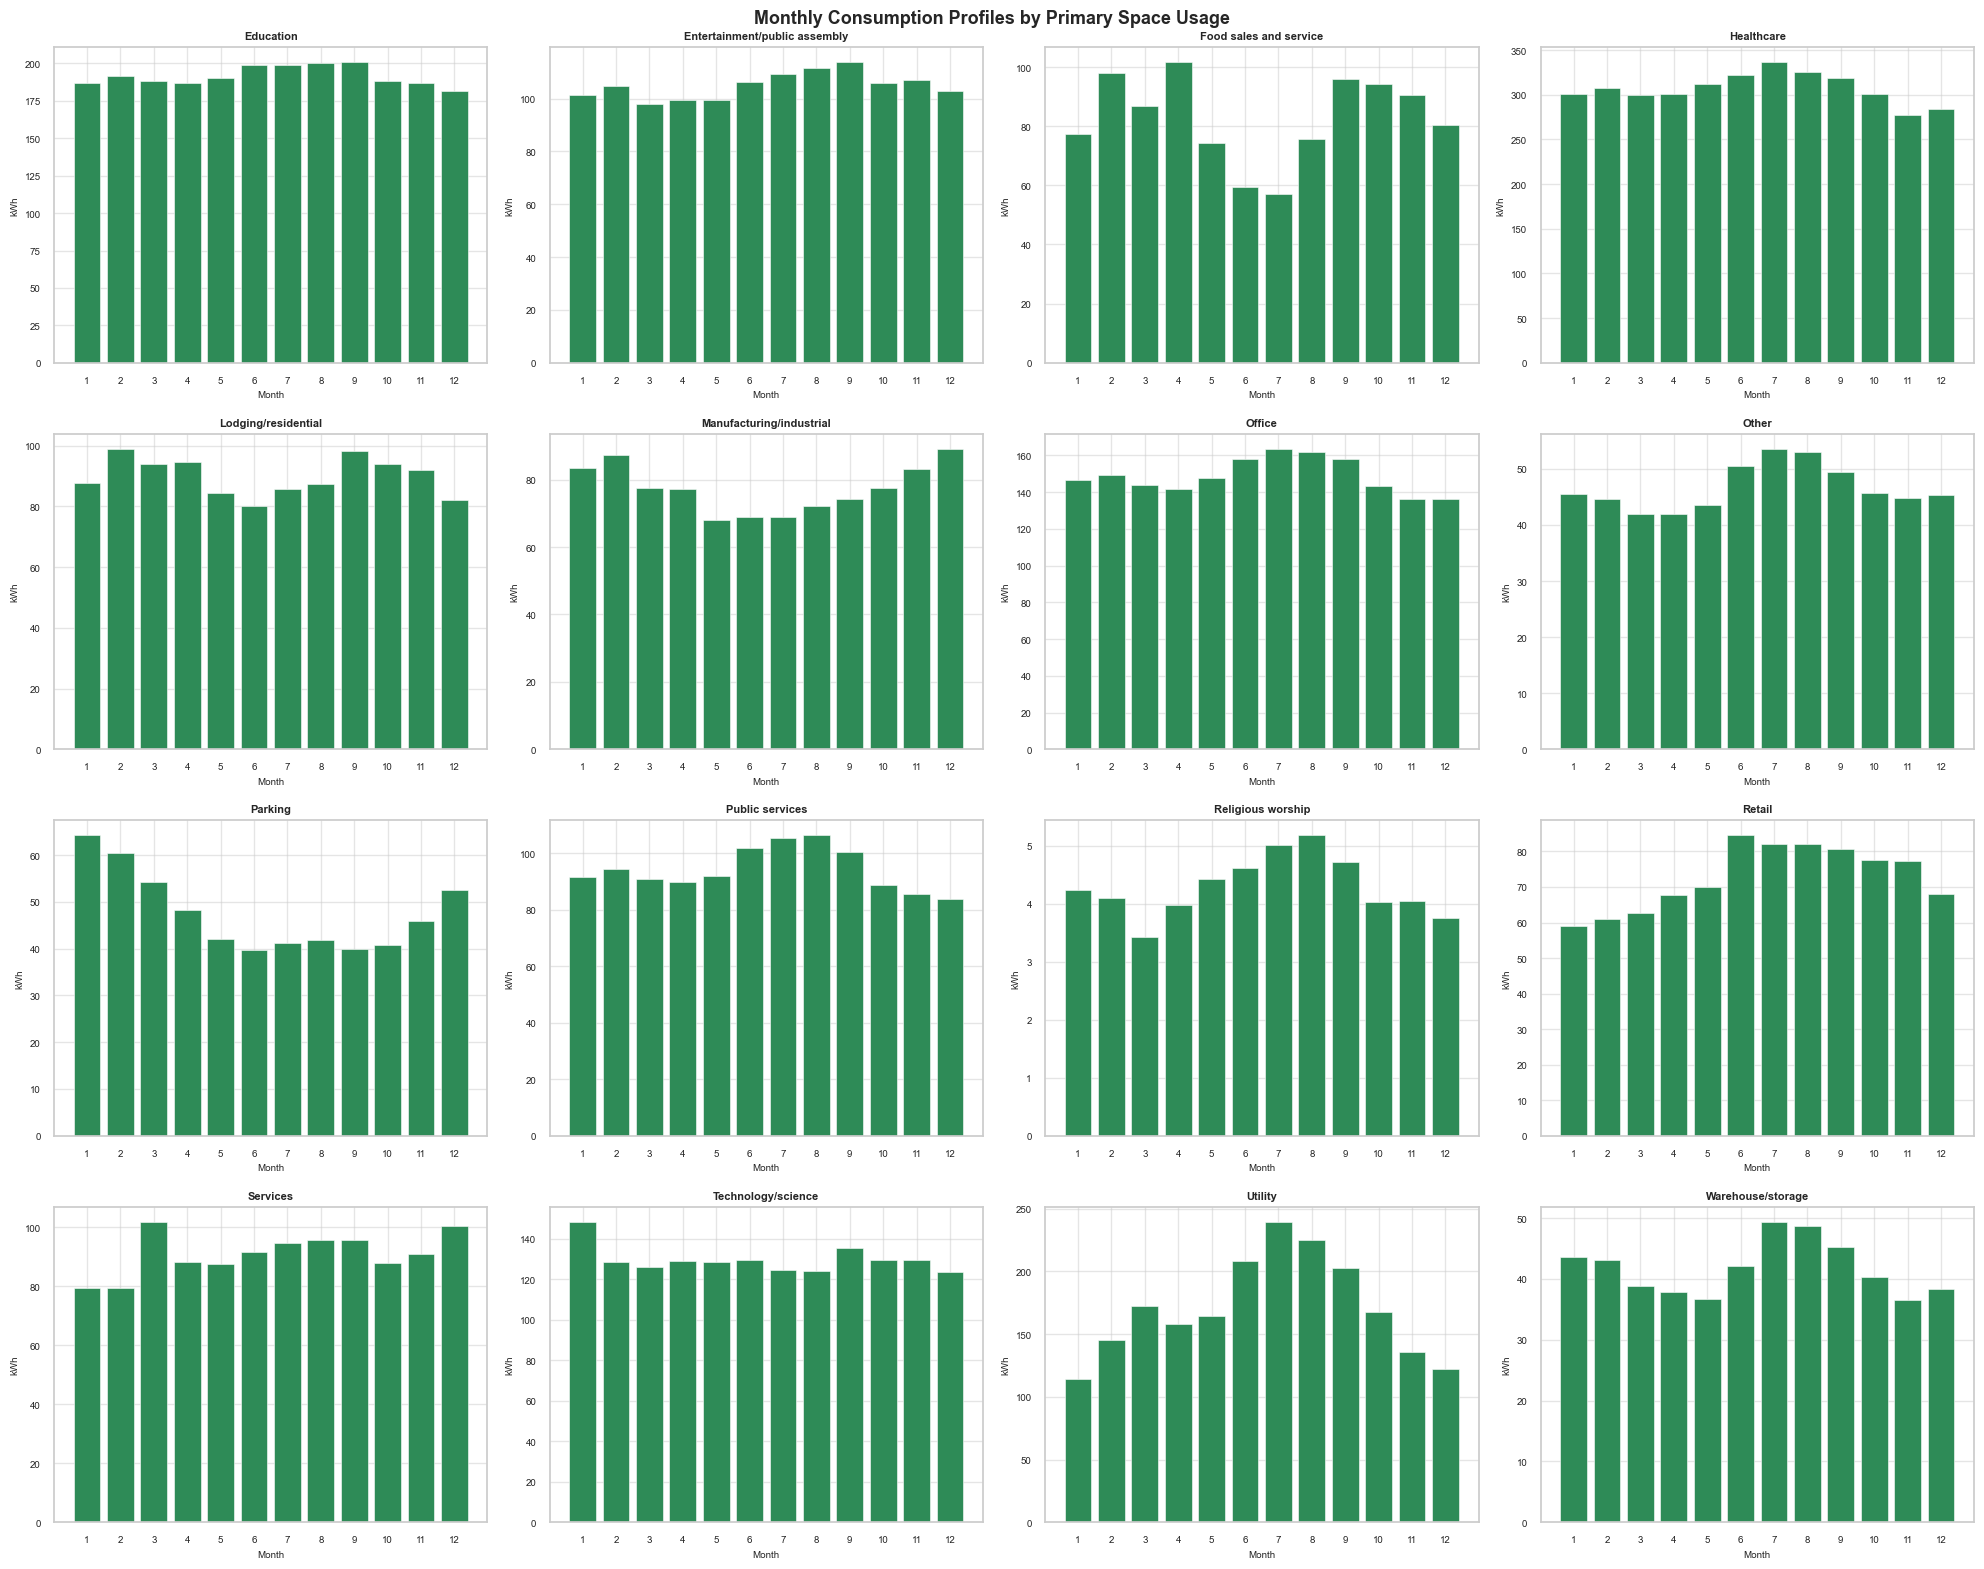

In [34]:
def usage_temporal_profile(usage, groupby_fn):
    cols = usage_to_blds[usage]
    usage_mean = elec_idx[cols].mean(axis=1)
    return usage_mean.groupby(groupby_fn(usage_mean.index)).mean()

usage_hourly   = {u: usage_temporal_profile(u, lambda idx: idx.hour)      for u in usages}
usage_dow      = {u: usage_temporal_profile(u, lambda idx: idx.dayofweek) for u in usages}
usage_monthly  = {u: usage_temporal_profile(u, lambda idx: idx.month)     for u in usages}

n_usages = len(usages)
NCOLS = 4
NROWS = (n_usages + NCOLS - 1) // NCOLS

# --- Hourly ---
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, NROWS * 4), sharey=False)
axes_flat = axes.flatten()
for i, usage in enumerate(usages):
    ax = axes_flat[i]
    p = usage_hourly[usage]
    ax.plot(p.index, p.values, marker='o', markersize=2.5, linewidth=1.4, color='steelblue')
    ax.set_title(usage, fontsize=8, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=7)
    ax.set_ylabel('kWh', fontsize=7)
    ax.set_xticks(range(0, 24, 4))
    ax.tick_params(labelsize=7)
for j in range(n_usages, NROWS * NCOLS):
    axes_flat[j].set_visible(False)
fig.suptitle('Hourly Consumption Profiles by Primary Space Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Day of week ---
bar_colors_dow = ['steelblue'] * 5 + ['tomato'] * 2
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, NROWS * 4), sharey=False)
axes_flat = axes.flatten()
for i, usage in enumerate(usages):
    ax = axes_flat[i]
    p = usage_dow[usage].reindex(range(7), fill_value=0)
    ax.bar(range(7), p.values, color=bar_colors_dow, edgecolor='white', linewidth=0.4)
    ax.set_title(usage, fontsize=8, fontweight='bold')
    ax.set_xlabel('Day', fontsize=7)
    ax.set_ylabel('kWh', fontsize=7)
    ax.set_xticks(range(7))
    ax.set_xticklabels(['M','T','W','Th','F','Sa','Su'], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
for j in range(n_usages, NROWS * NCOLS):
    axes_flat[j].set_visible(False)
legend_handles = [Patch(color='steelblue', label='Weekday'), Patch(color='tomato', label='Weekend')]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(0.99, 0.01), fontsize=9)
fig.suptitle('Day-of-Week Consumption Profiles by Primary Space Usage', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# --- Monthly ---
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, NROWS * 4), sharey=False)
axes_flat = axes.flatten()
for i, usage in enumerate(usages):
    ax = axes_flat[i]
    p = usage_monthly[usage].reindex(range(1, 13), fill_value=0)
    ax.bar(range(1, 13), p.values, color='seagreen', edgecolor='white', linewidth=0.4)
    ax.set_title(usage, fontsize=8, fontweight='bold')
    ax.set_xlabel('Month', fontsize=7)
    ax.set_ylabel('kWh', fontsize=7)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
for j in range(n_usages, NROWS * NCOLS):
    axes_flat[j].set_visible(False)
fig.suptitle('Monthly Consumption Profiles by Primary Space Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Consumption Distribution by Usage Type (Box Plot)

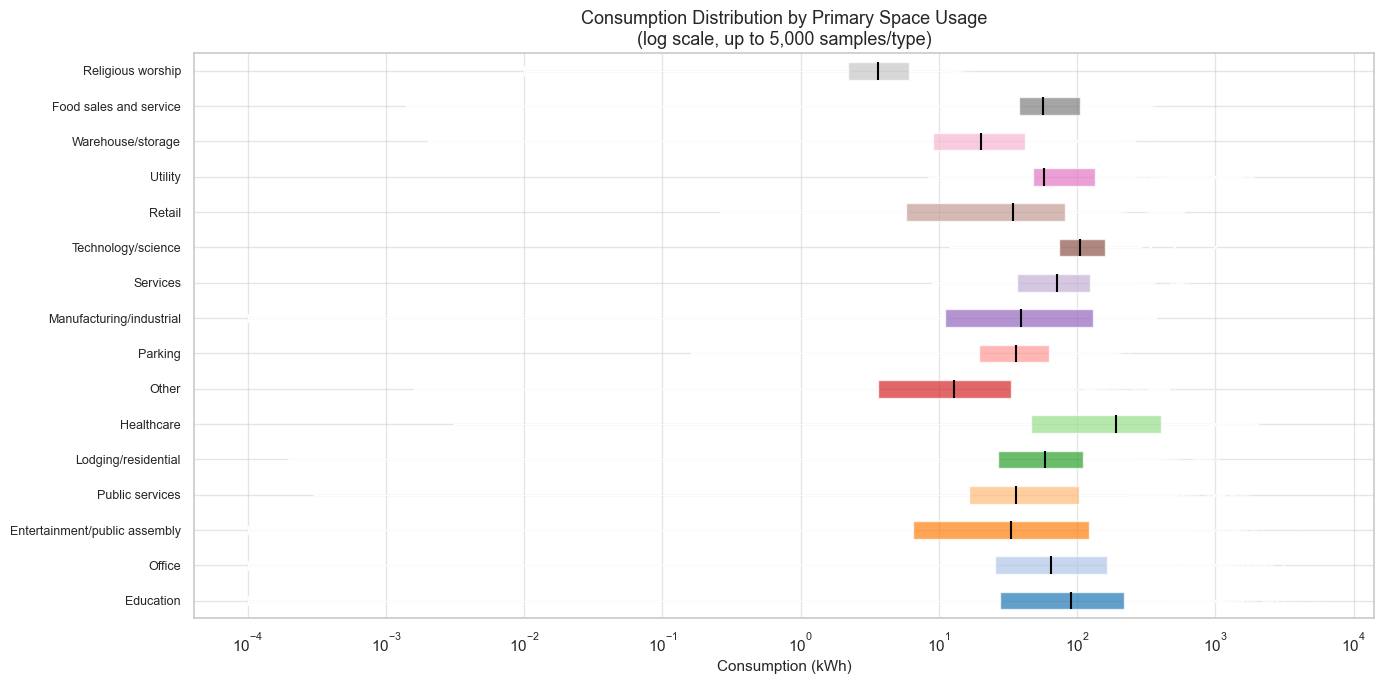

In [35]:
# Sample up to 5000 readings per usage type for box plot readability
rng = np.random.default_rng(42)

box_data  = []
box_labels = []
# Order by median descending
order_box = usage_cons_df['usage'].tolist()

for usage in order_box:
    cols = usage_to_blds[usage]
    vals = elec[cols].values.ravel()
    vals = vals[~np.isnan(vals)]
    if len(vals) > 5000:
        vals = rng.choice(vals, 5000, replace=False)
    box_data.append(vals)
    box_labels.append(usage)

fig, ax = plt.subplots(figsize=(14, 7))
bp = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
    boxprops=dict(alpha=0.7),
    showfliers=True,
)
colors_box = plt.cm.tab20.colors
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax.set_yticks(range(1, len(box_labels) + 1))
ax.set_yticklabels(box_labels, fontsize=9)
ax.set_xlabel('Consumption (kWh)')
ax.set_title('Consumption Distribution by Primary Space Usage\n(log scale, up to 5,000 samples/type)')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 6. Floor Area (sqm) by Usage Type

,usage,median_sqm,mean_sqm,std_sqm,n_with_sqm
0,Parking,"36,013","26,954","18,004",23
1,Services,"19,905","20,593","16,652",9
2,Education,"7,004","9,363","8,708",604
3,Healthcare,"6,916","12,413","15,790",27
4,Technology/science,"5,584","5,560","3,079",7
5,Lodging/residential,"5,392","7,947","8,738",149
6,Office,"4,852","7,982","10,333",296
7,Food sales and service,"3,183","3,526","1,503",6
8,Retail,"2,942","3,651","4,188",11
9,Entertainment/public assembly,"2,433","6,957","11,620",203


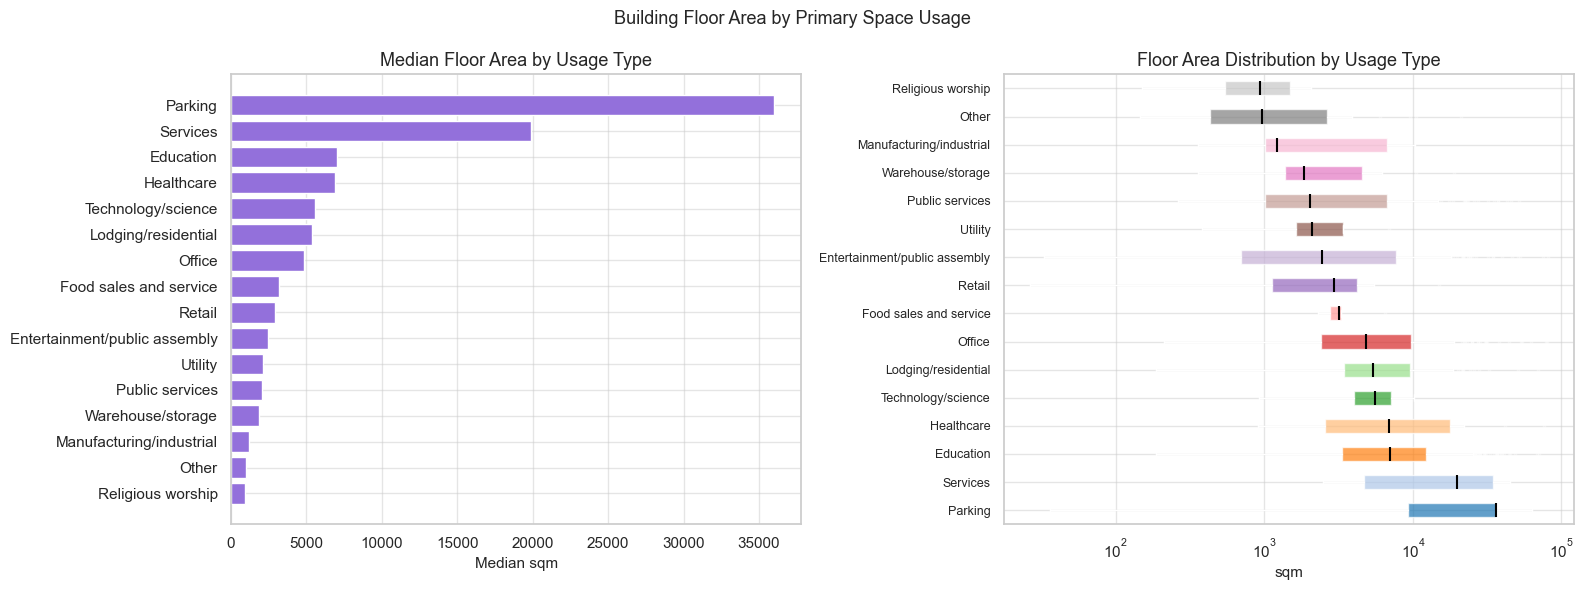

In [36]:
sqm_by_usage = (
    meta[meta['building_id'].isin(building_cols)]
    .groupby('primaryspaceusage')['sqm']
    .agg(['median', 'mean', 'std', 'count'])
    .rename(columns={'median': 'median_sqm', 'mean': 'mean_sqm', 'std': 'std_sqm', 'count': 'n_with_sqm'})
    .reset_index()
    .rename(columns={'primaryspaceusage': 'usage'})
    .sort_values('median_sqm', ascending=False)
    .reset_index(drop=True)
)

display(sqm_by_usage.style.format({
    'median_sqm': '{:,.0f}', 'mean_sqm': '{:,.0f}',
    'std_sqm': '{:,.0f}', 'n_with_sqm': '{:,}'
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_sqm = sqm_by_usage['usage'].tolist()
axes[0].barh(order_sqm, sqm_by_usage['median_sqm'], color='mediumpurple', edgecolor='white')
axes[0].set_title('Median Floor Area by Usage Type')
axes[0].set_xlabel('Median sqm')
axes[0].invert_yaxis()

# Box plot of sqm per usage type
sqm_box_data   = []
sqm_box_labels = []
for usage in order_sqm:
    vals = meta[
        (meta['building_id'].isin(building_cols)) &
        (meta['primaryspaceusage'] == usage)
    ]['sqm'].dropna().values
    sqm_box_data.append(vals)
    sqm_box_labels.append(usage)

bp2 = axes[1].boxplot(
    sqm_box_data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    boxprops=dict(alpha=0.7),
    showfliers=True,
)
for patch, color in zip(bp2['boxes'], plt.cm.tab20.colors):
    patch.set_facecolor(color)
axes[1].set_yticks(range(1, len(sqm_box_labels) + 1))
axes[1].set_yticklabels(sqm_box_labels, fontsize=9)
axes[1].set_xlabel('sqm')
axes[1].set_title('Floor Area Distribution by Usage Type')
axes[1].set_xscale('log')

plt.suptitle('Building Floor Area by Primary Space Usage', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Usage Type × Site Heatmap

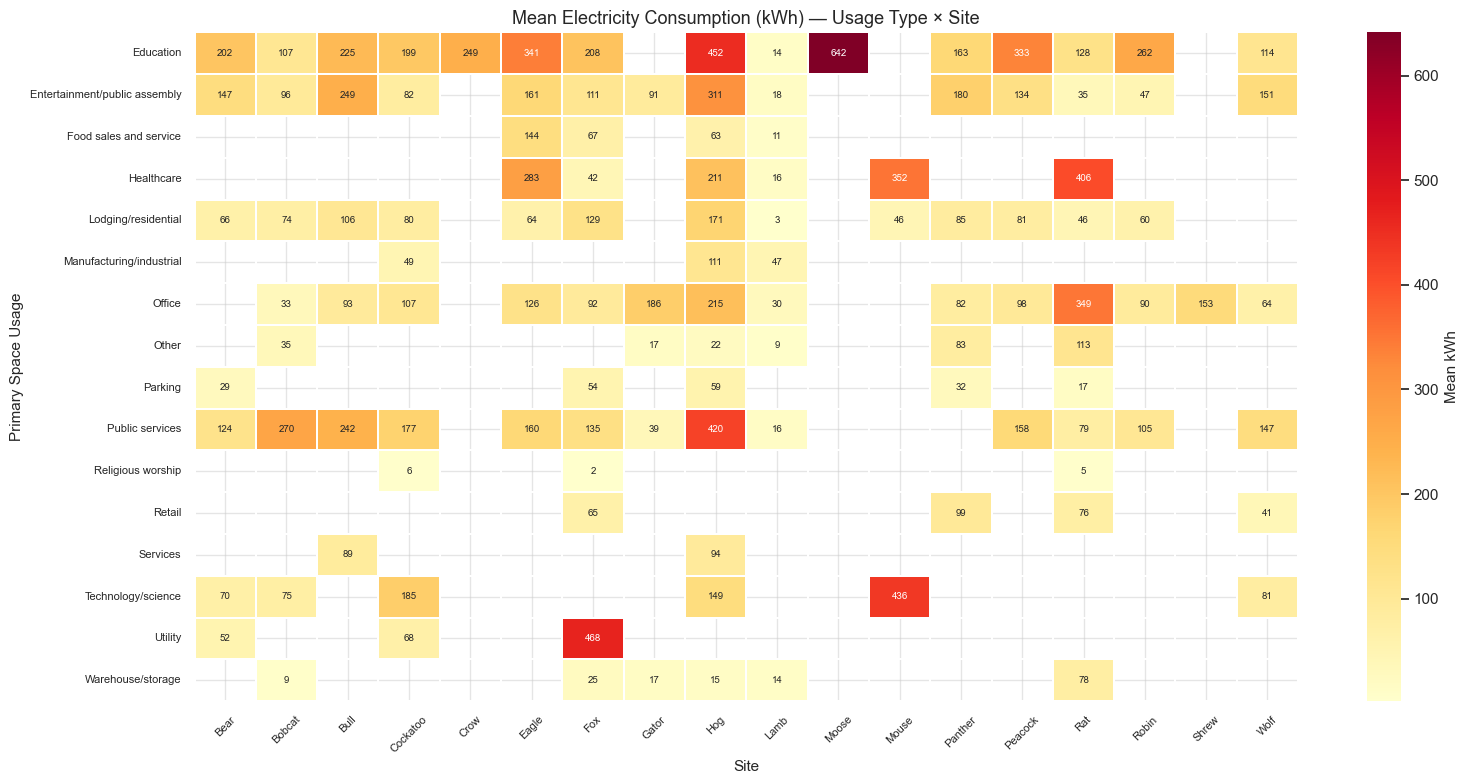

In [37]:
# Mean consumption per (usage_type, site) cell — useful for spotting outlier combos
meta_elec_full = meta[meta['building_id'].isin(building_cols)][
    ['building_id', 'site_id', 'primaryspaceusage']
].copy()

cross_stats = []
for _, row in meta_elec_full.iterrows():
    bld, site, usage = row['building_id'], row['site_id'], row['primaryspaceusage']
    if pd.isna(usage):
        continue
    vals = elec[bld].dropna().values
    if len(vals):
        cross_stats.append({'site': site, 'usage': usage, 'mean_kwh': vals.mean()})

cross_df = pd.DataFrame(cross_stats)
pivot_mean = cross_df.groupby(['usage', 'site'])['mean_kwh'].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(16, 8))
mask = pivot_mean.isna()
sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    mask=mask,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Mean kWh'},
)
ax.set_title('Mean Electricity Consumption (kWh) — Usage Type × Site', fontsize=13)
ax.set_xlabel('Site')
ax.set_ylabel('Primary Space Usage')
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.show()

## Summary Observations

- **Usage categories are imbalanced**: Education dominates with 604 electricity buildings, followed by Office (296), Entertainment/public assembly (203), Public services (166), and Lodging/residential (149). Small categories such as Utility and Religious worship should be interpreted cautiously.
- **Healthcare is the highest-load usage type**: Healthcare averages about 308 kWh per reading, roughly 2x the global dataset average, despite having only 27 buildings. Education and Utility are also high-load categories.
- **Low-load usage types need different thresholds**: Religious worship, Parking, and Warehouse/storage have much lower average consumption. A threshold that is sensible for Healthcare or Education can be too aggressive for these groups.
- **Missingness varies by usage**: Technology/science has the highest missing rate at about 19%, followed by Parking near 13%, with Entertainment/public assembly and Retail around 11%. Usage-level model evaluation should account for these quality differences.
- **Temporal profiles differ by usage**: Education, Office, and Public services show daytime and weekday-heavy patterns; Lodging/residential is flatter with an evening peak and a near-1.0 weekday/weekend ratio.
- **High within-type variability argues against one-size-fits-all rules**: Other, Office, Entertainment/public assembly, and Public services have high internal variation, so anomaly thresholds should prefer per-building baselines over broad usage-level constants.
- **Anomaly-detection implication**: Healthcare and Education should be prioritized because of their high absolute load, while Lodging/residential and Parking need looser flatline logic because always-on or low-load behavior is more common.
